# Taller de Redes Neuronales

- **Punto 1:** Redes neuronales para las compuertas lógicas **NAND** y **XOR** (descripción de las redes).
- **Punto 2:** Clasificación de prendas de vestir con **Fashion MNIST** y TensorFlow.

# Punto 1. Redes neuronales para las compuertas NAND y XOR

Las compuertas lógicas se pueden representar con redes neuronales cuyos pesos se eligen de forma que la salida reproduzca la tabla de verdad. En ambas redes cada capa incluye una neurona de **sesgo** (el nodo con valor "1") y se usa una función de activación sigmoide, que con pesos grandes (±10, ±20, ±30) se comporta casi como un interruptor de 0 a 1.

| x1 | x2 | NAND | XOR |
|:-:|:-:|:-:|:-:|
| 0 | 0 | 1 | 0 |
| 0 | 1 | 1 | 1 |
| 1 | 0 | 1 | 1 |
| 1 | 1 | 0 | 0 |

## 1.1 Red neuronal para la compuerta NAND

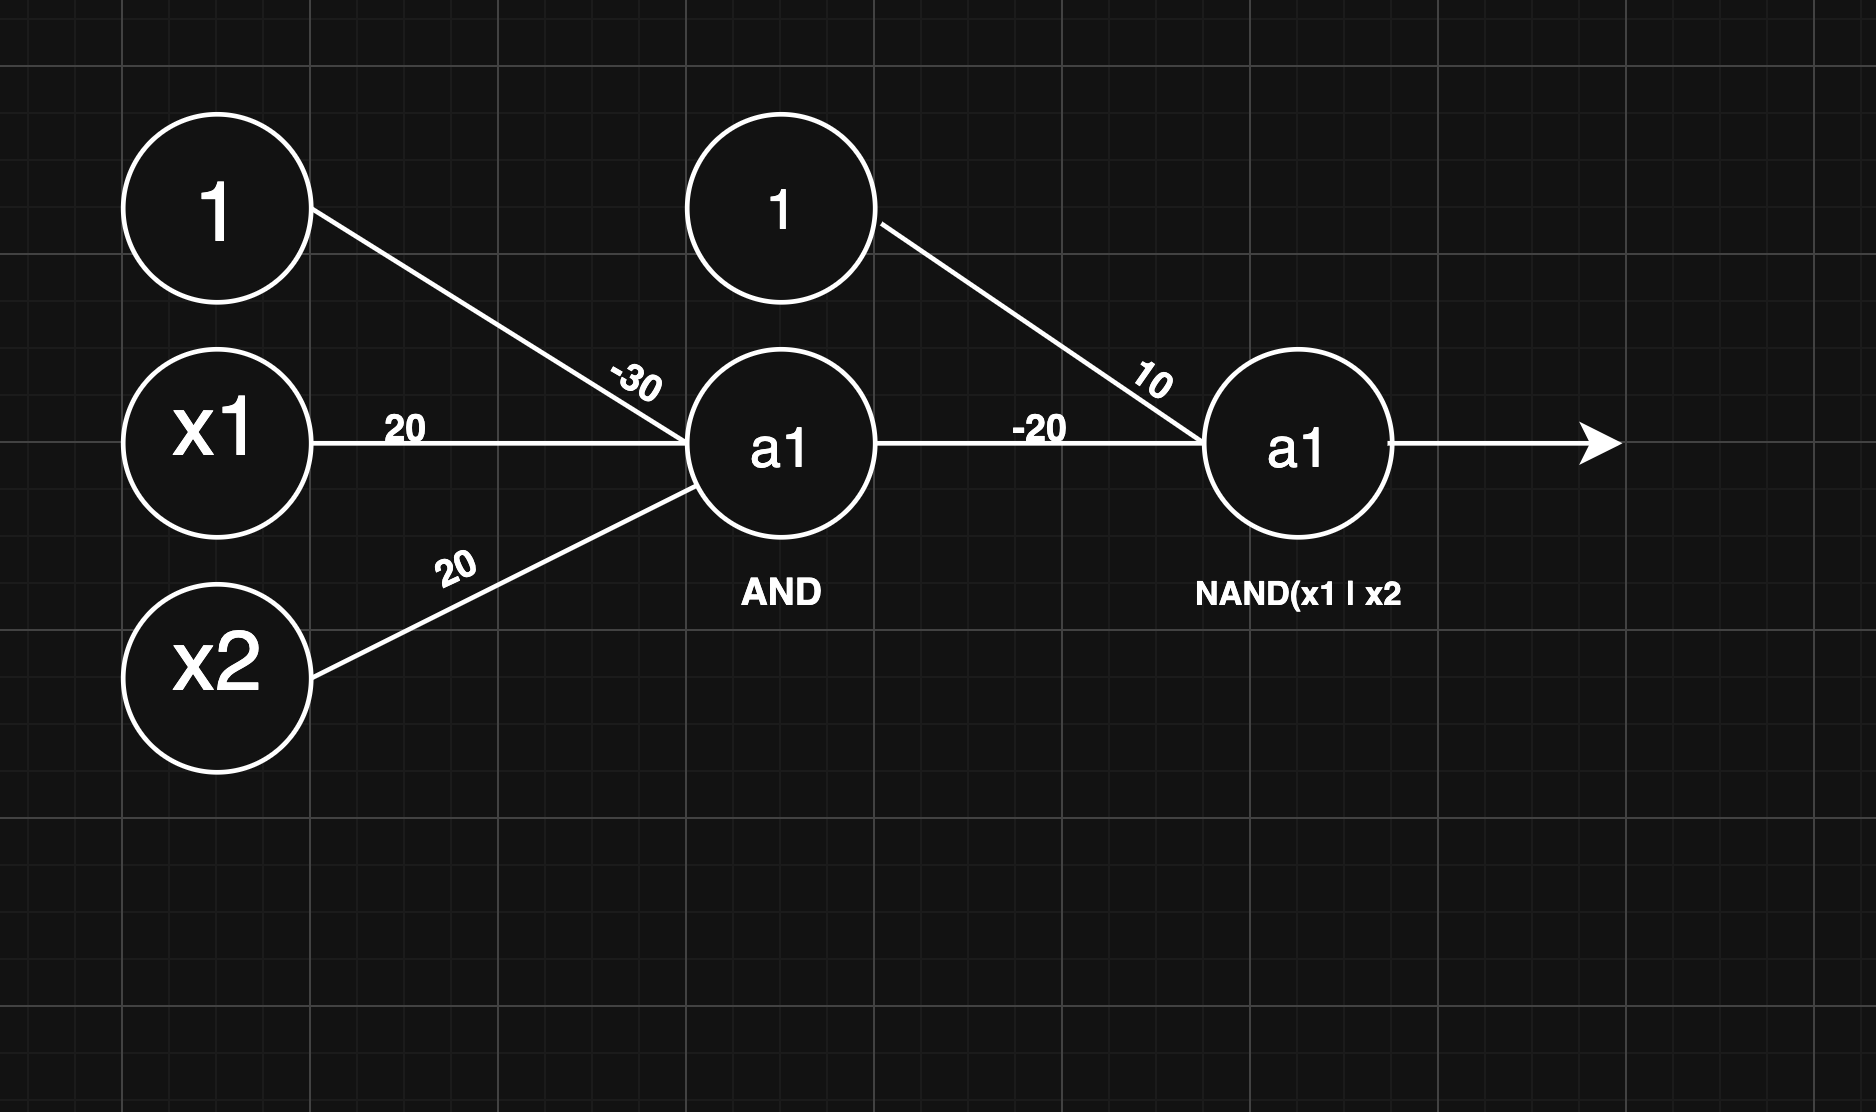

La red tiene una capa oculta con una sola neurona y una neurona de salida.

- **Capa oculta (a1), compuerta AND:** recibe el sesgo con peso **-30** y las entradas x1 y x2 con peso **20** cada una. Solo se activa cuando x1 = 1 y x2 = 1, porque -30 + 20 + 20 = 10 es positivo; en cualquier otro caso la suma es negativa.
- **Capa de salida (a1), negación:** recibe el sesgo con peso **10** y la salida del AND con peso **-20**, de modo que invierte el resultado del AND.
- **Resultado:** la salida es 1, 1, 1, 0 para (0,0), (0,1), (1,0), (1,1). Es decir, **NAND = NOT(AND)**.

## 1.2 Red neuronal para la compuerta XOR


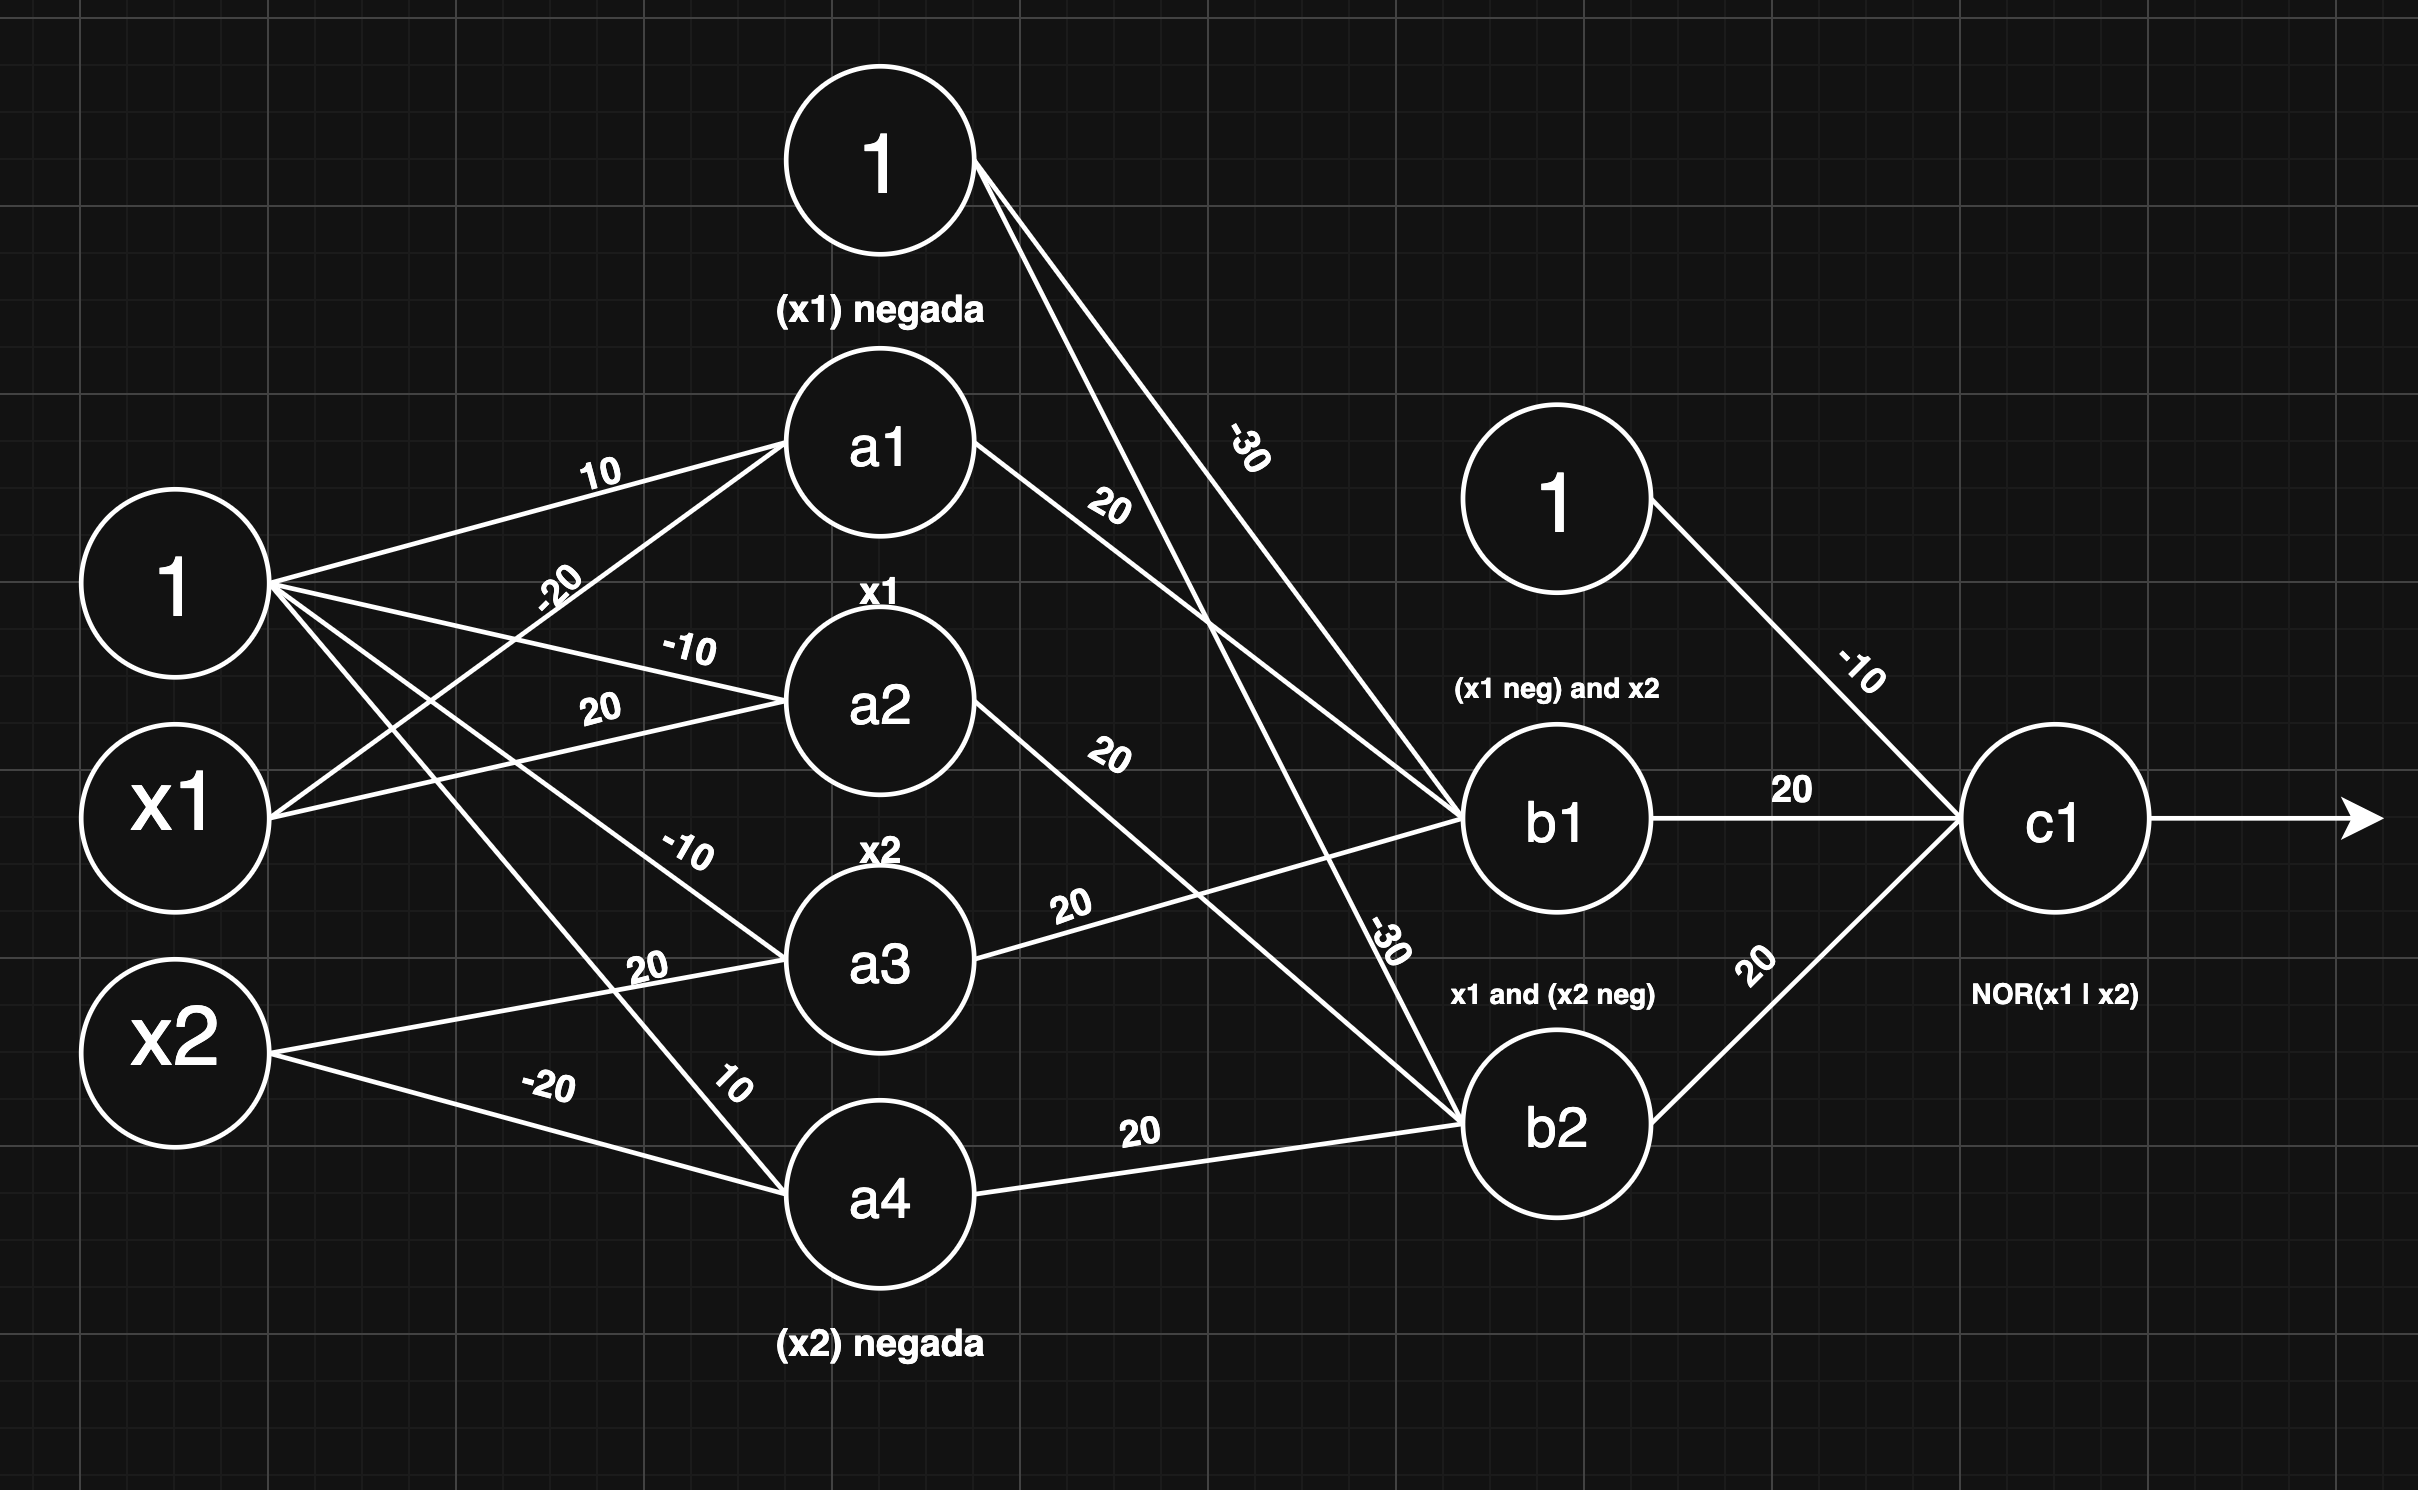
La red tiene **dos capas ocultas** y una neurona de salida (c1). El XOR no puede resolverse con una sola neurona porque sus salidas no son linealmente separables, por eso se combinan varias compuertas simples.

- **Primera capa oculta (a1 a a4):** prepara las entradas y sus negaciones.
  - a1 = x1 negada (sesgo 10, peso -20).
  - a2 = x1 (sesgo -10, peso 20).
  - a3 = x2 (sesgo -10, peso 20).
  - a4 = x2 negada (sesgo 10, peso -20).
- **Segunda capa oculta (b1 y b2):** aplica compuertas AND sobre esas señales, ambas con sesgo -30 y pesos de 20.
  - b1 = (x1 negada) AND x2, a partir de a1 y a3.
  - b2 = x1 AND (x2 negada), a partir de a2 y a4.
- **Salida (c1):** sesgo -10 y pesos de 20 desde b1 y b2. Se activa si alguna de las dos es 1, o sea un **OR** entre b1 y b2.
- **Resultado:** la salida es 0, 1, 1, 0 para (0,0), (0,1), (1,0), (1,1): vale 1 solo cuando x1 y x2 son distintas, que es el **XOR**.

> **Nota:** en el diagrama la salida aparece rotulada como "NOR(x1 | x2)", pero con estos pesos c1 realiza un OR de b1 y b2 y la red completa calcula un XOR. Un NOR daría 1, 0, 0, 0.



---

# Punto 2. Clasificación de prendas de vestir con Fashion MNIST y TensorFlow



### Paso 1. Importar librerías
- `tensorflow`: framework de deep learning.
- `keras`: API de alto nivel para construir redes.
- `numpy`: manejo de arreglos numéricos.
- `matplotlib`: gráficos.
- `sklearn.metrics`: matriz de confusión y reporte de clasificación.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("Versión de TensorFlow:", tf.__version__)

Versión de TensorFlow: 2.20.0


### Paso 2. Descargar el data set
`keras.datasets.fashion_mnist.load_data()` descarga automáticamente el data set (70.000 imágenes) y lo devuelve ya dividido en:
- **Entrenamiento:** 60.000 imágenes + etiquetas.
- **Prueba:** 10.000 imágenes + etiquetas.

Cada etiqueta es un número de 0 a 9, por lo que definimos una lista con los nombres de las clases.

In [2]:
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla deportiva', 'Bolso', 'Botín']

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### Paso 3. Exploración de los datos
- `.shape`: dimensiones del arreglo.
- `np.unique(..., return_counts=True)`: cuántas imágenes hay por clase (el data set está balanceado).
- Los píxeles son enteros entre 0 (negro) y 255 (blanco).

In [3]:
print("Entrenamiento:", train_images.shape, train_labels.shape)
print("Prueba:       ", test_images.shape, test_labels.shape)
print("Rango de píxeles:", train_images.min(), "a", train_images.max())

clases, cuentas = np.unique(train_labels, return_counts=True)
for c, n in zip(clases, cuentas):
    print(f"{c} - {class_names[c]}: {n} imágenes")

Entrenamiento: (60000, 28, 28) (60000,)
Prueba:        (10000, 28, 28) (10000,)
Rango de píxeles: 0 a 255
0 - Camiseta/Top: 6000 imágenes
1 - Pantalón: 6000 imágenes
2 - Suéter: 6000 imágenes
3 - Vestido: 6000 imágenes
4 - Abrigo: 6000 imágenes
5 - Sandalia: 6000 imágenes
6 - Camisa: 6000 imágenes
7 - Zapatilla deportiva: 6000 imágenes
8 - Bolso: 6000 imágenes
9 - Botín: 6000 imágenes


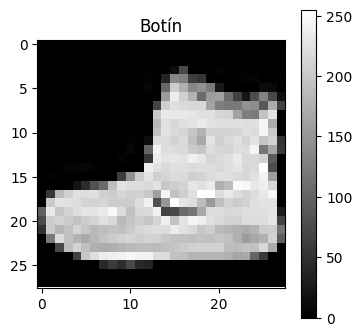

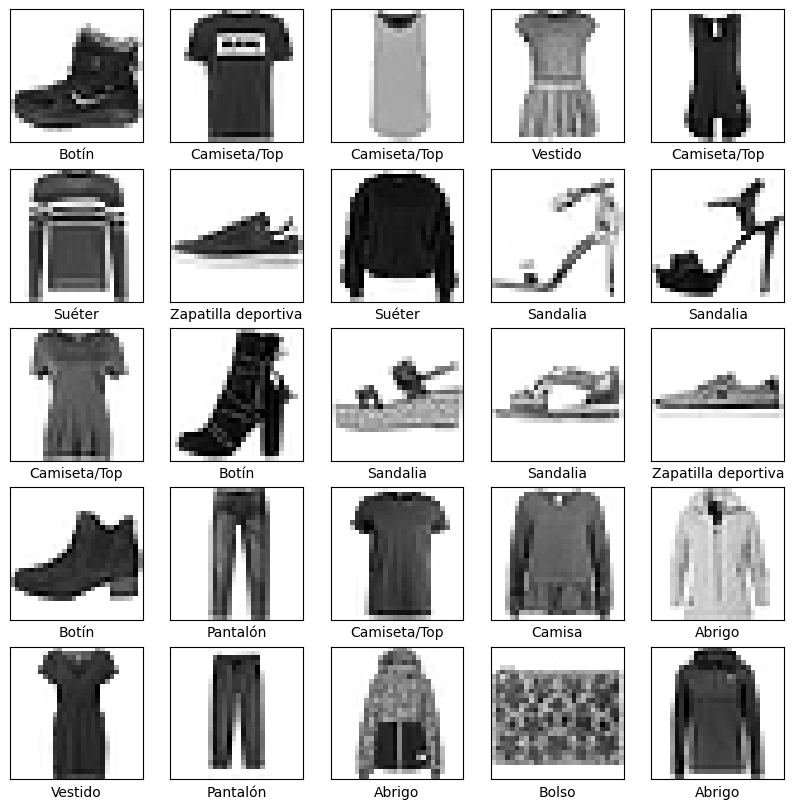

In [4]:
# Una imagen individual
plt.figure(figsize=(4,4))
plt.imshow(train_images[0], cmap='gray')
plt.colorbar()
plt.title(class_names[train_labels[0]])
plt.grid(False)
plt.show()

# Cuadrícula con las primeras 25 imágenes
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([]); plt.yticks([]); plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

### Paso 4. Preprocesamiento
Se **normalizan** los píxeles dividiendo entre 255 para llevarlos al rango [0, 1]. Esto acelera y estabiliza el entrenamiento, porque los pesos de la red trabajan mejor con valores pequeños.

In [5]:
train_images = train_images / 255.0
test_images  = test_images / 255.0

### Paso 5. Construcción del modelo (red neuronal densa)
`keras.Sequential` apila capas una tras otra:

| Capa | Función |
|---|---|
| `Flatten(input_shape=(28,28))` | Convierte cada imagen 28×28 en un vector de 784 valores. No tiene parámetros que aprender. |
| `Dense(128, activation='relu')` | Capa oculta con 128 neuronas. **ReLU** = `max(0, x)`: introduce no linealidad para aprender patrones complejos. |
| `Dropout(0.2)` | Apaga aleatoriamente el 20 % de las neuronas en cada paso de entrenamiento para reducir el sobreajuste. |
| `Dense(10, activation='softmax')` | Capa de salida: 10 neuronas (una por clase). **Softmax** convierte las salidas en probabilidades que suman 1. |

In [6]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation='softmax')
])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Paso 6. Compilación
`model.compile()` define cómo aprende la red:
- **`optimizer='adam'`**: algoritmo que ajusta los pesos; adapta la tasa de aprendizaje automáticamente.
- **`loss='sparse_categorical_crossentropy'`**: función de pérdida para clasificación multiclase cuando las etiquetas son enteros (0–9). Mide qué tan lejos está la probabilidad predicha de la clase correcta.
- **`metrics=['accuracy']`**: porcentaje de aciertos que se reporta en cada época.

In [7]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Paso 7. Entrenamiento
`model.fit()` ajusta los pesos:
- `epochs=15`: número de pasadas completas sobre los datos de entrenamiento.
- `batch_size=32`: cantidad de imágenes procesadas antes de actualizar los pesos.
- `validation_split=0.1`: reserva el 10 % del entrenamiento para validar en cada época y detectar sobreajuste.
- `EarlyStopping`: detiene el entrenamiento si la pérdida de validación deja de mejorar y restaura los mejores pesos.

In [8]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3,
                                           restore_best_weights=True)

history = model.fit(train_images, train_labels,
                    epochs=15,
                    batch_size=32,
                    validation_split=0.1,
                    callbacks=[early_stop])

Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8094 - loss: 0.5434 - val_accuracy: 0.8537 - val_loss: 0.4055
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8526 - loss: 0.4056 - val_accuracy: 0.8633 - val_loss: 0.3709
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8649 - loss: 0.3717 - val_accuracy: 0.8713 - val_loss: 0.3636
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8713 - loss: 0.3507 - val_accuracy: 0.8768 - val_loss: 0.3472
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8777 - loss: 0.3329 - val_accuracy: 0.8785 - val_loss: 0.3412
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8825 - loss: 0.3188 - val_accuracy: 0.8755 - val_loss: 0.3306
Epoch 7/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8877 - loss: 0.3067 - val_accuracy: 0.8777 - val_loss: 0.3324
Epoch 8/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8884 - loss: 0.2996 - 

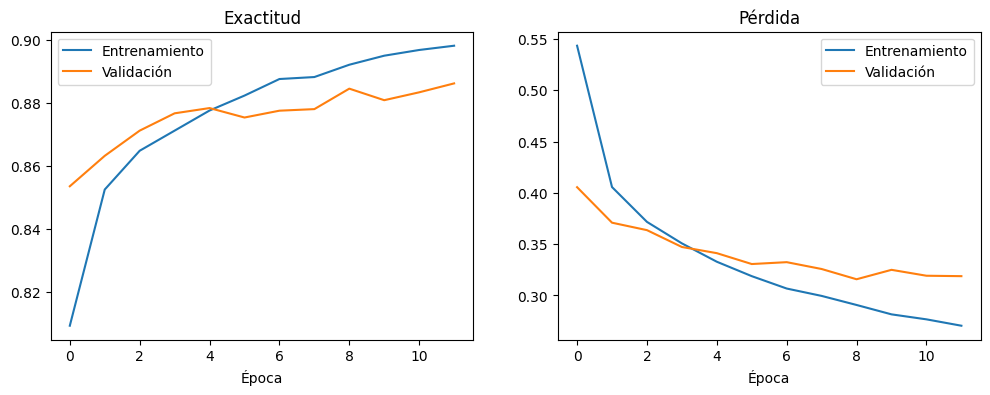

In [14]:
# Curvas de aprendizaje
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(history.history['accuracy'], label='Entrenamiento')
ax[0].plot(history.history['val_accuracy'], label='Validación')
ax[0].set_title('Exactitud'); ax[0].set_xlabel('Época'); ax[0].legend()
ax[1].plot(history.history['loss'], label='Entrenamiento')
ax[1].plot(history.history['val_loss'], label='Validación')
ax[1].set_title('Pérdida'); ax[1].set_xlabel('Época'); ax[1].legend()
plt.show()

### Paso 8. Evaluación
`model.evaluate()` calcula la pérdida y la exactitud sobre el conjunto de **prueba**, datos que la red nunca vio durante el entrenamiento.

In [15]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nExactitud en prueba: {test_acc:.4f}")

313/313 - 1s - 2ms/step - accuracy: 0.8793 - loss: 0.3393

Exactitud en prueba: 0.8793


### Paso 9. Predicciones
`model.predict()` devuelve, para cada imagen, un vector con 10 probabilidades. `np.argmax()` elige la clase con mayor probabilidad.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


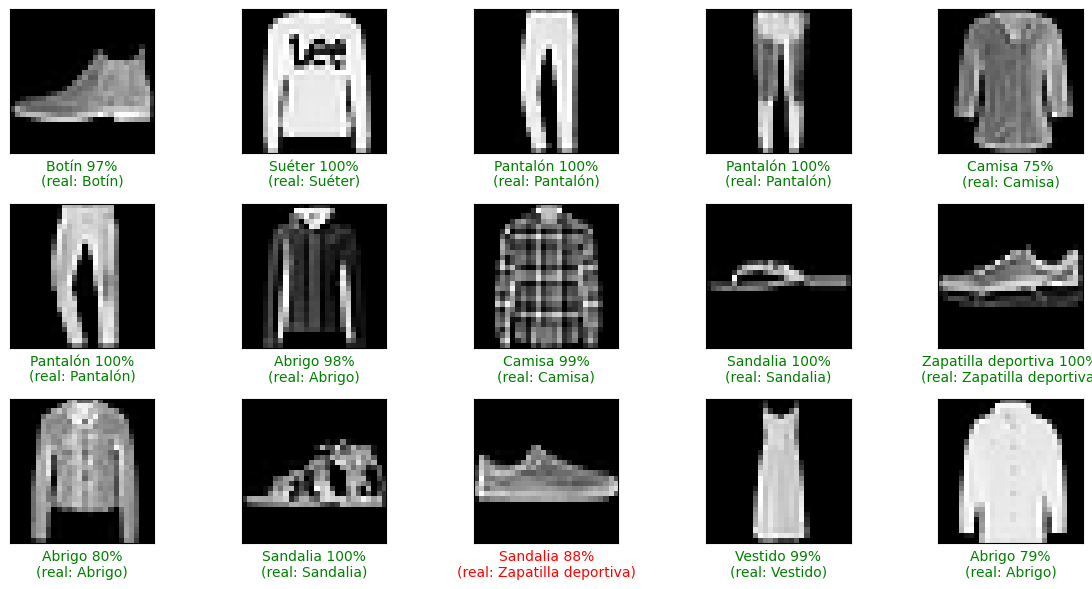

In [17]:
probs = model.predict(test_images)
pred_labels = np.argmax(probs, axis=1)

def mostrar(i):
    plt.imshow(test_images[i], cmap='gray'); plt.xticks([]); plt.yticks([])
    color = 'green' if pred_labels[i] == test_labels[i] else 'red'
    plt.xlabel(f"{class_names[pred_labels[i]]} {100*np.max(probs[i]):.0f}%\n(real: {class_names[test_labels[i]]})",
               color=color)

plt.figure(figsize=(12,6))
for k in range(15):
    plt.subplot(3,5,k+1); mostrar(k)
plt.tight_layout(); plt.show()

### Matriz de confusión y métricas por clase
Muestra qué clases se confunden entre sí. El reporte da *precision*, *recall* y *F1* para cada prenda.

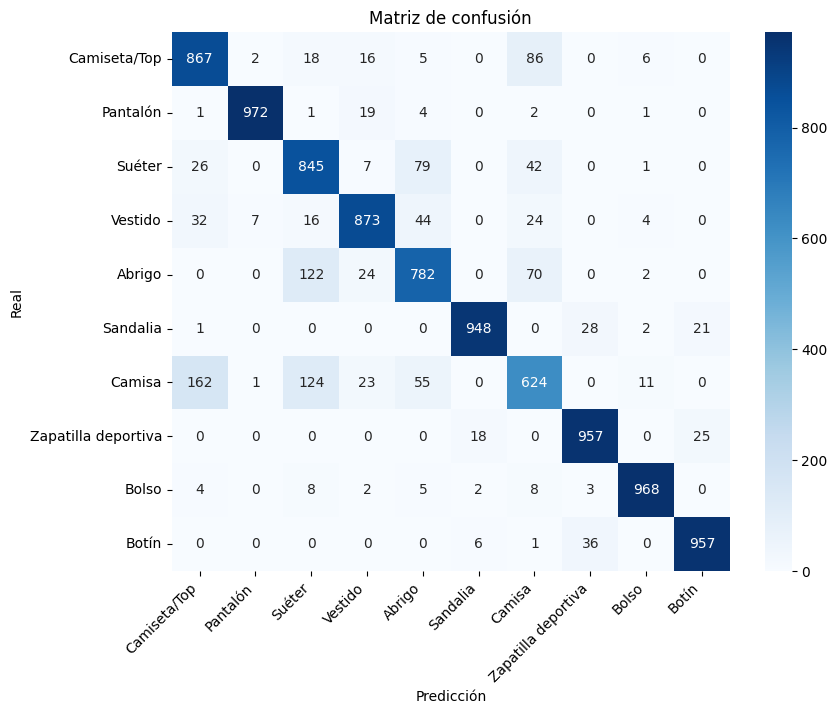

                     precision    recall  f1-score   support

       Camiseta/Top       0.79      0.87      0.83      1000
           Pantalón       0.99      0.97      0.98      1000
             Suéter       0.75      0.84      0.79      1000
            Vestido       0.91      0.87      0.89      1000
             Abrigo       0.80      0.78      0.79      1000
           Sandalia       0.97      0.95      0.96      1000
             Camisa       0.73      0.62      0.67      1000
Zapatilla deportiva       0.93      0.96      0.95      1000
              Bolso       0.97      0.97      0.97      1000
              Botín       0.95      0.96      0.96      1000

           accuracy                           0.88     10000
          macro avg       0.88      0.88      0.88     10000
       weighted avg       0.88      0.88      0.88     10000



In [12]:
cm = confusion_matrix(test_labels, pred_labels)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción'); plt.ylabel('Real'); plt.title('Matriz de confusión')
plt.xticks(rotation=45, ha='right'); plt.show()

print(classification_report(test_labels, pred_labels, target_names=class_names))

### Paso 11. Conclusiones

1. **Rendimiento:** la red densa simple suele alcanzar cerca de **88–89 %** de exactitud en prueba (los valores exactos varían en cada ejecución por la inicialización aleatoria).
2. **Clases fáciles:** pantalón, bolso, botín, sandalia y zapatilla tienen formas muy distintas y se clasifican con alta precisión.
3. **Clases difíciles:** *camiseta/top*, *camisa*, *suéter* y *abrigo* se confunden entre sí por tener siluetas similares; se ve en la matriz de confusión y en el menor F1 de la clase *camisa*.
4. **Posibles mejoras:** aumento de datos (*data augmentation*), ajuste de hiperparámetros o *transfer learning*.